# 🗺️ Análisis del Marco Maestro Rural Agropecuario (MMRA)

**Fuente**: DANE (Geoportal - Capa de Conglomerados 2025)

**Objetivo**: Explorar y validar la cobertura de los conglomerados rurales del Valle del Cauca, su vocación económica, y su uso como base espacial del modelo de zonificación agroclimática.

---

## Contenido
1. Carga de datos MMRA Tabulares
2. Análisis de Vocación Predominante (Uso del Suelo)
3. Distribución Geográfica por Municipio
4. Carga y Visualización de la Geometría (Mapa de Conglomerados)
5. Análisis Local: Municipio Específico (Palmira)
6. Cruce con Evaluaciones Agropecuarias (EVA)
7. Cruce Espacial: MMRA vs Zonificación Agrícola (UPRA)

In [1]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Rutas
BASE_DIR = Path('.').resolve().parent
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
REPORTS_DIR = DATA_DIR / 'reports'

print('Configuración lista')

Configuración lista


## 1. Carga de datos Tabulares del MMRA
Primero cargaremos la versión procesada en CSV que generamos con el script para hacer la estadística descriptiva rápidamente.

In [2]:
tabular_file = PROCESSED_DIR / 'mmra_conglomerados_valle_tabular.csv'

if not tabular_file.exists():
    print("ERROR: No se encontró el archivo tabular del MMRA.")
    print("Asegúrate de ejecutar primero en tu terminal: python scripts/10_download_mmra_dane.py")
else:
    df_mmra = pd.read_csv(tabular_file)
    print(f"Total de Conglomerados Rurales (Valle del Cauca): {len(df_mmra):,}")
    print("\nPrimeros 3 registros:")
    display(df_mmra.head(3))

Total de Conglomerados Rurales (Valle del Cauca): 9,365

Primeros 3 registros:


,OBJECTID,COD_DEPTO,COD_ZBIOF,CONGLOMERADO,NOMBREDEPARTAMENTO_CG,NOMBREMUNICIPIO_CG,DIVIPOLA_CG,USO_PRED_CONGL,AREA_CONGLO_HA,PISO_TERMICO,COD_PTERMICO,RANGO_PENDIENTE,COD_PENDIENTE,COD_AREA_HIDROG,COD_ZONA_HIDROG,NOM_AREA_HIDROG,NOM_ZONA_HIDROG
0,52177,76,23554.0,768630032000,VALLE DEL CAUCA,VERSALLES,76863,Pastos,455.167300,TEMPLADO,2.0,ESCARPADO,3.0,5.0,54.0,Pacífico,San Juan
1,52178,76,23554.0,768630033000,VALLE DEL CAUCA,VERSALLES,76863,Cultivos Permanentes,54.457887,TEMPLADO,2.0,ESCARPADO,3.0,5.0,54.0,Pacífico,San Juan
2,52179,76,23554.0,768630034000,VALLE DEL CAUCA,VERSALLES,76863,Cultivos Permanentes,207.850977,TEMPLADO,2.0,ESCARPADO,3.0,5.0,54.0,Pacífico,San Juan


## 2. Análisis de Vocación Predominante (Uso del Suelo)
El DANE clasifica cada conglomerado según su uso (Bosque Natural, Cultivos Transitorios, Pastos, etc.).

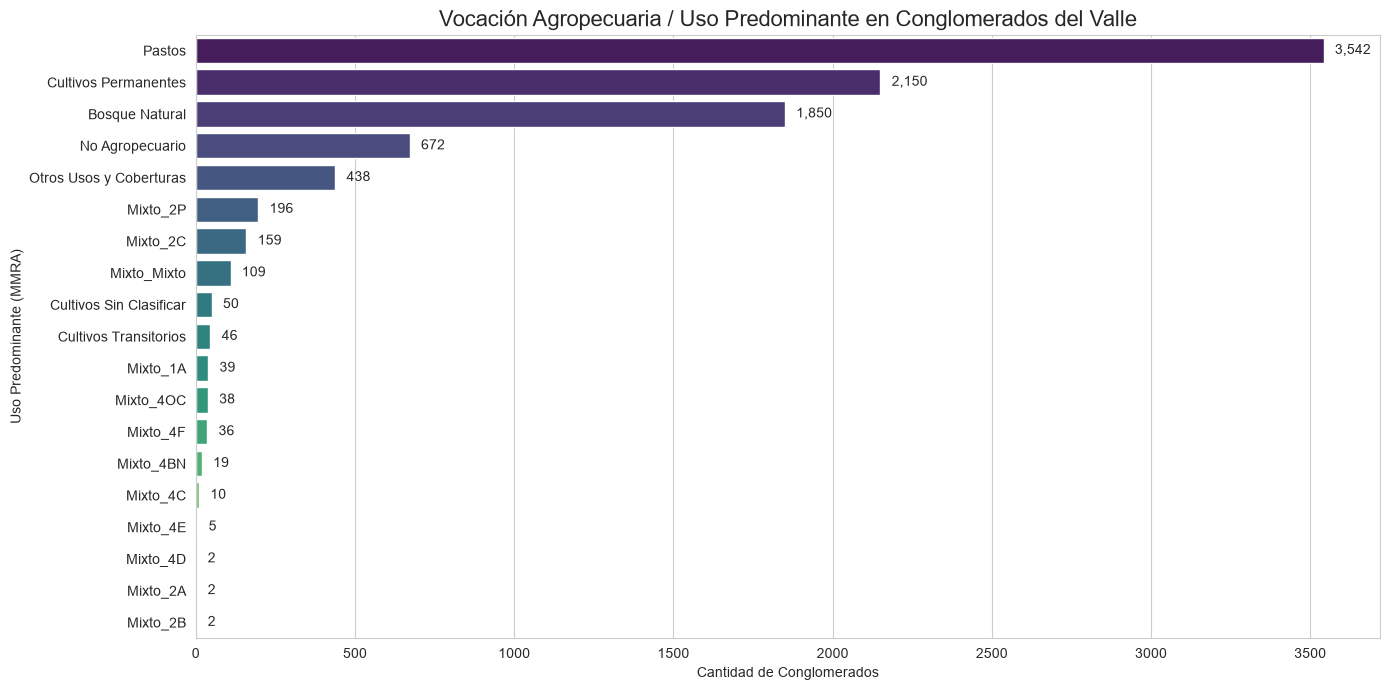


Área Total Aproximada por Uso (Hectáreas):


,AREA_CONGLO_HA
USO_PRED_CONGL,
Bosque Natural,"849,379.5"
Pastos,"642,564.6"
Cultivos Permanentes,"343,028.7"
No Agropecuario,"48,036.8"
Mixto_Mixto,"44,361.3"
Mixto_2P,"40,257.0"
Otros Usos y Coberturas,"32,944.7"
Mixto_2C,"29,954.5"
Mixto_4OC,"14,544.3"


In [3]:
if 'df_mmra' in locals() and 'USO_PRED_CONGL' in df_mmra.columns:
    usos_count = df_mmra['USO_PRED_CONGL'].value_counts()

    plt.figure(figsize=(14, 7))
    sns.barplot(x=usos_count.values, y=usos_count.index, palette='viridis')
    plt.title('Vocación Agropecuaria / Uso Predominante en Conglomerados del Valle', fontsize=16)
    plt.xlabel('Cantidad de Conglomerados')
    plt.ylabel('Uso Predominante (MMRA)')
    
    for i, v in enumerate(usos_count.values):
        plt.text(v + (usos_count.max() * 0.01), i, f'{v:,}', va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()
    
    # Área Total Aproximada (si está disponible)
    if 'AREA_CONGLO_HA' in df_mmra.columns:
        area_uso = df_mmra.groupby('USO_PRED_CONGL')['AREA_CONGLO_HA'].sum().sort_values(ascending=False)
        print("\nÁrea Total Aproximada por Uso (Hectáreas):")
        display(area_uso.to_frame().style.format('{:,.1f}'))

## 3. Distribución Geográfica por Municipio
Como el MMRA incluye TODOS los municipios rurales del departamento, verifiquemos cuáles tienen mayor cantidad de conglomerados.

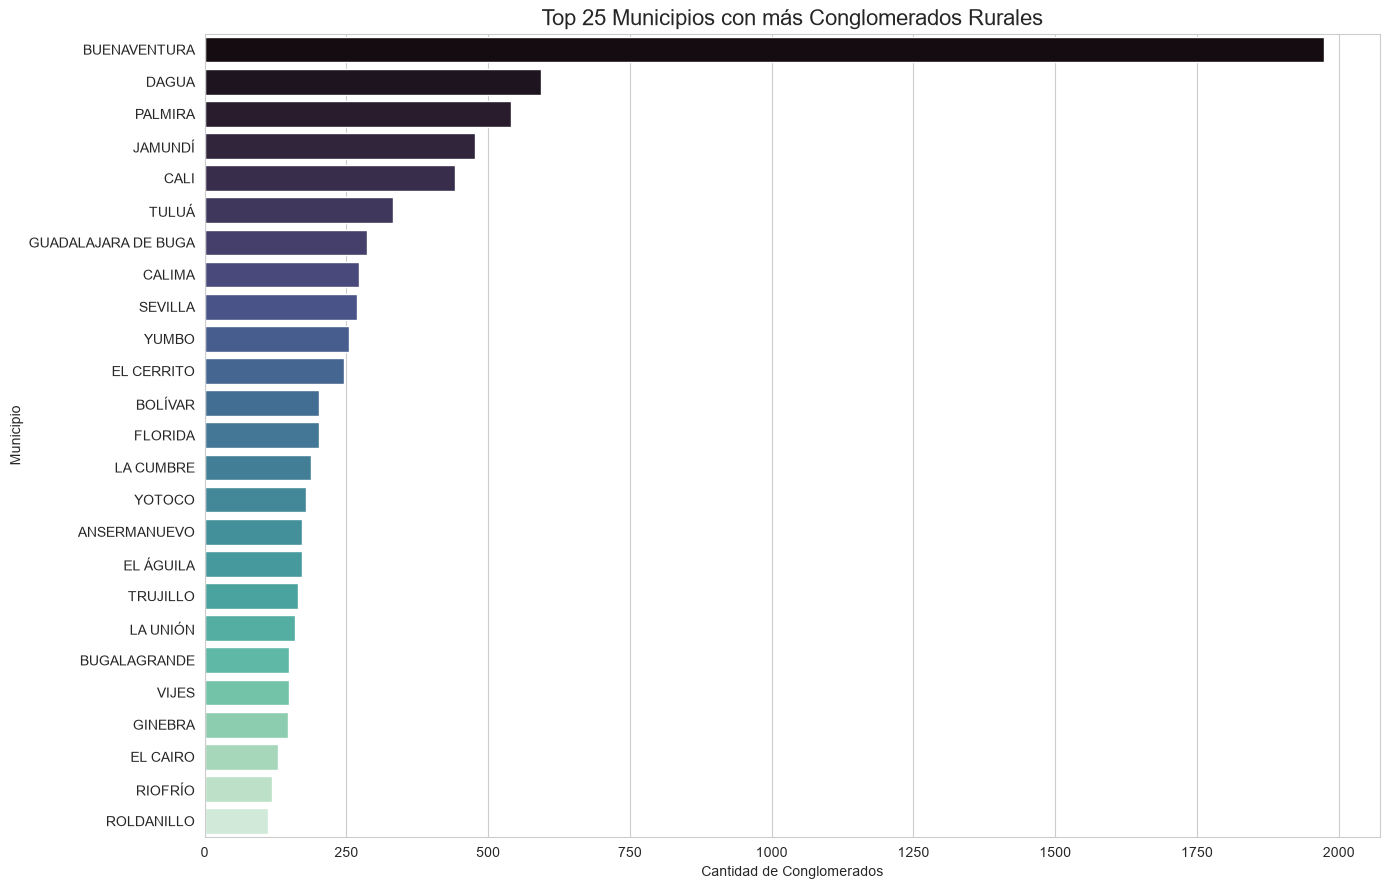

In [4]:
if 'df_mmra' in locals() and 'NOMBREMUNICIPIO_CG' in df_mmra.columns:
    munis_count = df_mmra['NOMBREMUNICIPIO_CG'].value_counts().head(25)
    
    plt.figure(figsize=(14, 9))
    sns.barplot(x=munis_count.values, y=munis_count.index, palette='mako')
    plt.title('Top 25 Municipios con más Conglomerados Rurales', fontsize=16)
    plt.xlabel('Cantidad de Conglomerados')
    plt.ylabel('Municipio')
    plt.tight_layout()
    plt.show()

## 4. Carga y Visualización de la Geometría (Mapa de Conglomerados)
Dado que los conglomerados son muchos menos que los predios catastrales (generalmente unos miles frente a 360 mil), sí podemos graficarlos usando `geopandas`.

Cargando geometrías del MMRA... (Esto puede tomar un minuto)

Geometrías cargadas exitosamente: 9,365 polígonos


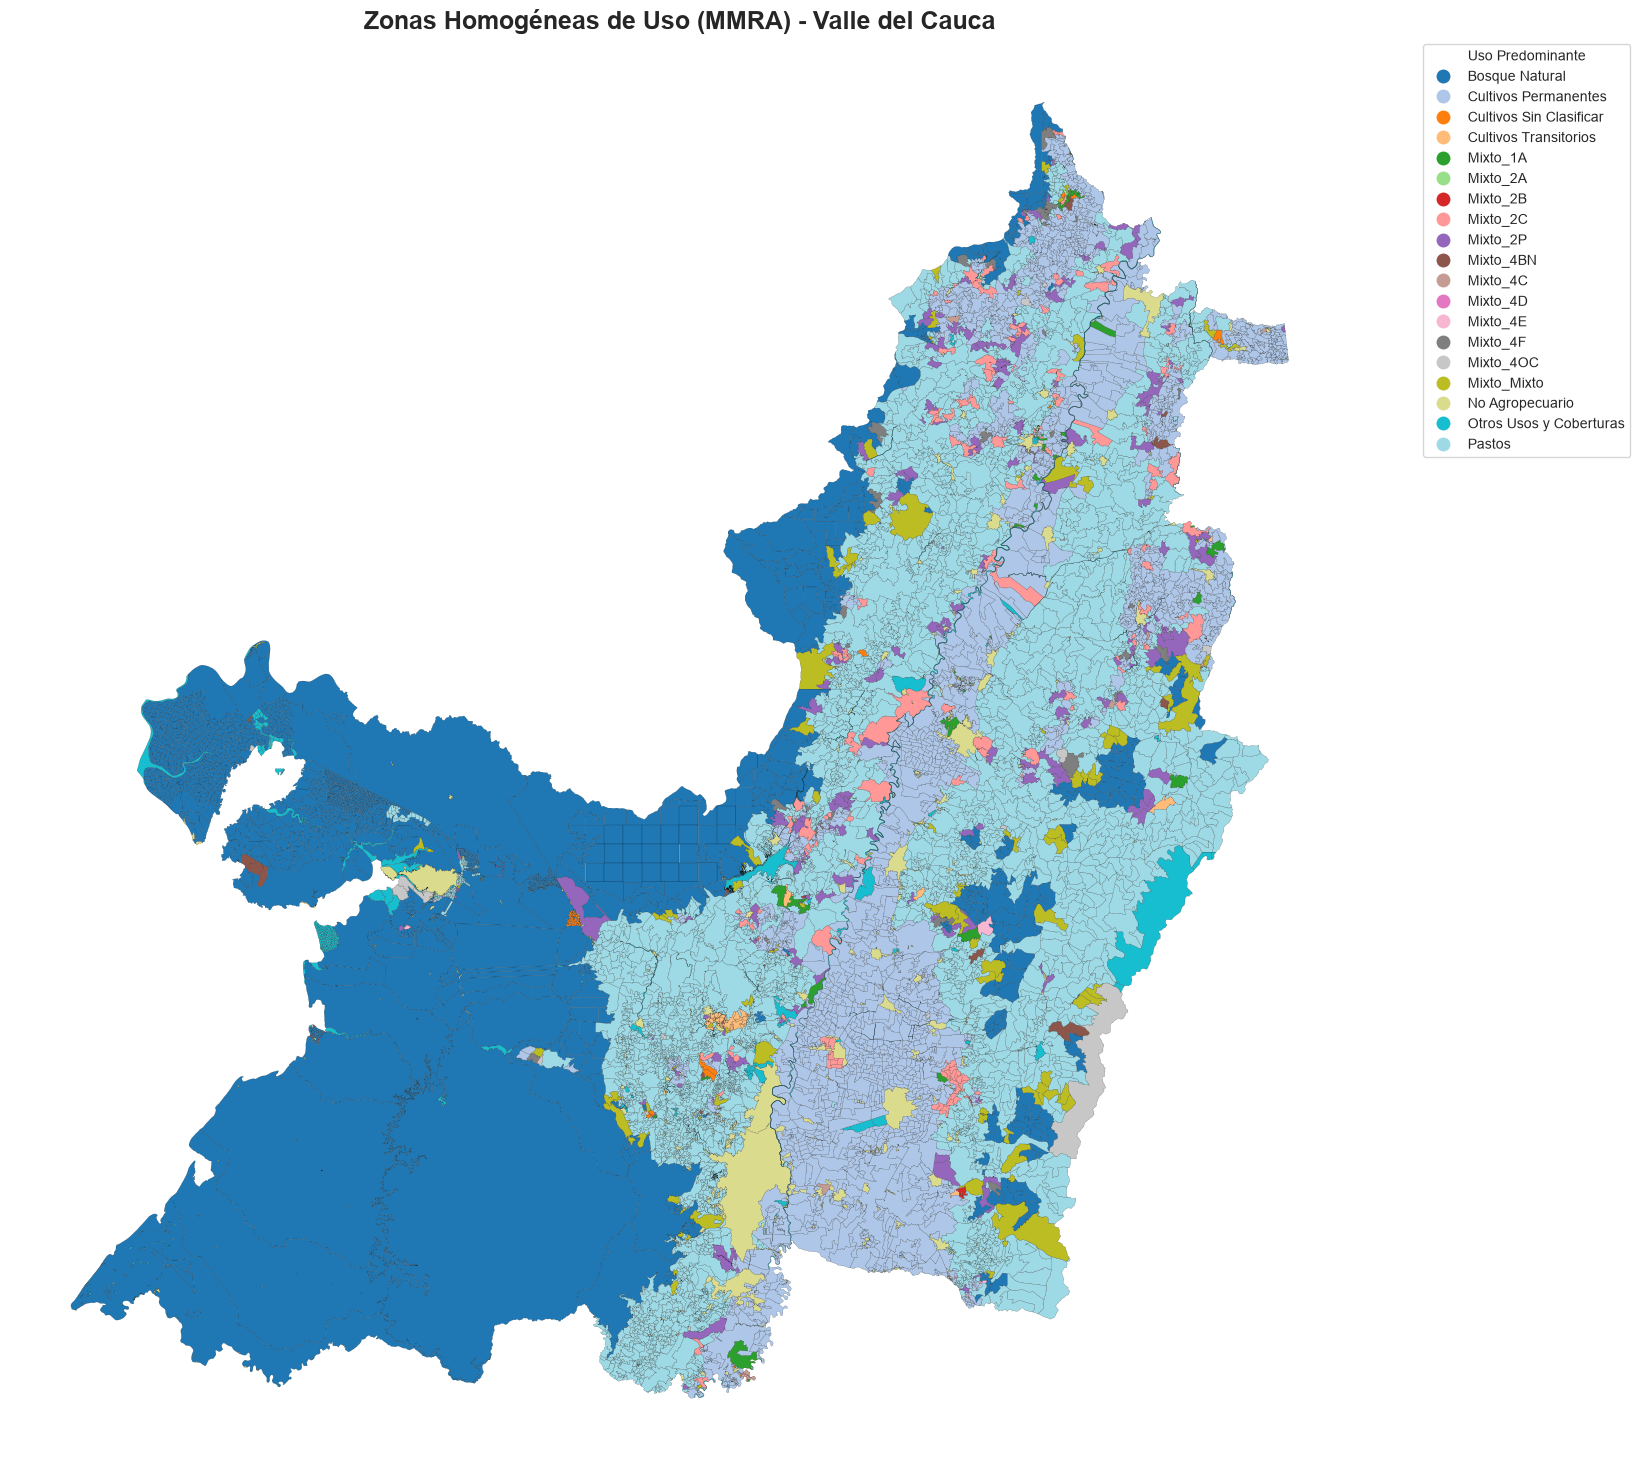

In [5]:
geojson_file = RAW_DIR / 'mmra_conglomerados_valle.geojson'

if geojson_file.exists():
    try:
        import geopandas as gpd
        
        print("Cargando geometrías del MMRA... (Esto puede tomar un minuto)")
        gdf_mmra = gpd.read_file(geojson_file)
        print(f"\nGeometrías cargadas exitosamente: {len(gdf_mmra):,} polígonos")
        
        # Graficar todo el departamento coloreado por USO PREDOMINANTE
        fig, ax = plt.subplots(figsize=(16, 16))
        
        # Colorear por uso
        gdf_mmra.plot(column='USO_PRED_CONGL', 
                      ax=ax, 
                      legend=True, 
                      cmap='tab20', 
                      edgecolor='black', 
                      linewidth=0.1, 
                      legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left', 'title': 'Uso Predominante'})
                      
        ax.set_title('Zonas Homogéneas de Uso (MMRA) - Valle del Cauca', fontsize=18, fontweight='bold')
        ax.axis('off')
        
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'fig_mapa_mmra_usos.png', dpi=150)
        plt.show()
        
    except ImportError:
        print("GeoPandas no está instalado. Para graficar, ejecuta en tu entorno:")
        print("pip install geopandas shapely")
else:
    print("El archivo GeoJSON no existe aún.")

## 5. Análisis Local: Municipio Específico (Palmira)
Filtraremos el conjunto de datos espaciales para visualizar únicamente los conglomerados de un municipio de interés.

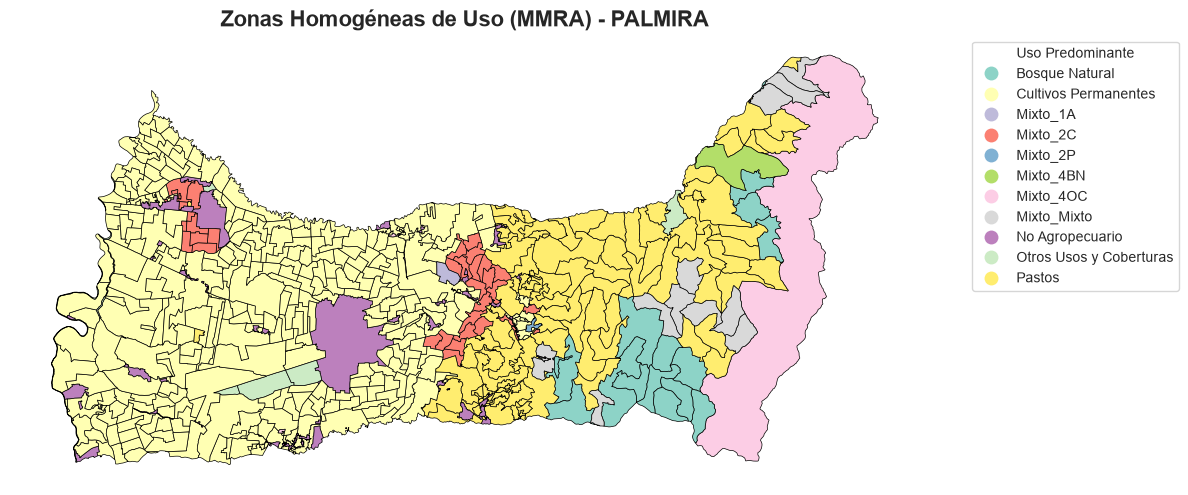

Área total agrupada por uso en PALMIRA (Hectáreas):


,AREA_CONGLO_HA
USO_PRED_CONGL,
Cultivos Permanentes,"44,915.6"
Pastos,"23,024.7"
Mixto_4OC,"11,817.4"
Bosque Natural,"6,904.4"
No Agropecuario,"4,376.3"
Mixto_Mixto,"3,786.3"
Mixto_2C,"3,046.4"
Otros Usos y Coberturas,"1,317.7"
Mixto_4BN,"1,124.4"


In [6]:
if 'gdf_mmra' in locals():
    municipio_objetivo = 'PALMIRA'
    # Limpiar strings para evitar errores de coincidencia
    gdf_mmra['NOMBREMUNICIPIO_CG'] = gdf_mmra['NOMBREMUNICIPIO_CG'].astype(str).str.strip().str.upper()
    gdf_local = gdf_mmra[gdf_mmra['NOMBREMUNICIPIO_CG'] == municipio_objetivo]
    
    if not gdf_local.empty:
        fig, ax = plt.subplots(figsize=(12, 10))
        gdf_local.plot(column='USO_PRED_CONGL', 
                       ax=ax, 
                       legend=True, 
                       cmap='Set3', 
                       edgecolor='black', 
                       linewidth=0.5,
                       legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left', 'title': 'Uso Predominante'})
        ax.set_title(f'Zonas Homogéneas de Uso (MMRA) - {municipio_objetivo}', fontsize=16, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / f'fig_mapa_mmra_{municipio_objetivo.lower()}.png', dpi=150)
        plt.show()
        
        print(f"Área total agrupada por uso en {municipio_objetivo} (Hectáreas):")
        display(gdf_local.groupby('USO_PRED_CONGL')['AREA_CONGLO_HA'].sum().to_frame().sort_values(by='AREA_CONGLO_HA', ascending=False).style.format('{:,.1f}'))
    else:
        print(f"No se encontraron conglomerados para el municipio: {municipio_objetivo}")

## 6. Cruce con Evaluaciones Agropecuarias (EVA)
Vamos a cargar los datos del EVA y compararlos con el uso del suelo agrícola del MMRA para ver su consistencia.

In [7]:
eva_file = PROCESSED_DIR / 'eva_valle_cultivos_interes.csv'

if eva_file.exists():
    df_eva = pd.read_csv(eva_file)
    print(f"Registros EVA cargados: {len(df_eva):,}")
    
    # Filtrar datos de EVA para el municipio objetivo (último año disponible)
    df_eva_local = df_eva[df_eva['municipio'].str.upper().str.strip() == municipio_objetivo]
    
    if not df_eva_local.empty:
        ultimo_anio = df_eva_local['anio'].max()
        df_eva_recent = df_eva_local[df_eva_local['anio'] == ultimo_anio]
        
        print(f"\nProducción y Área en {municipio_objetivo} según EVA (Año {ultimo_anio}):")
        
        resumen_eva = df_eva_recent.groupby('cultivo')[['area_sembrada_ha', 'area_cosechada_ha', 'produccion_ton']].sum()
        display(resumen_eva.sort_values('area_sembrada_ha', ascending=False).style.format('{:,.1f}'))
        
        # Comparación general de áreas agrícolas MMRA vs EVA
        if 'gdf_local' in locals() and not gdf_local.empty:
            print("\n--- Comparativa Rápida (Suelo Agrícola) ---")
            # Filtramos todos los usos que puedan tener cultivos en el MMRA
            usos_agricolas = ['Cultivos Permanentes', 'Cultivos Transitorios', 'Cultivos Sin Clasificar', 'Mixto_1A', 'Mixto_2A', 'Mixto_4A', 'Mixto_Mixto']
            area_agricola_mmra = gdf_local[gdf_local['USO_PRED_CONGL'].isin(usos_agricolas)]['AREA_CONGLO_HA'].sum()
            area_sembrada_eva = resumen_eva['area_sembrada_ha'].sum()
            
            print(f"Área total de Vocación Agrícola pura o Mixta en MMRA: {area_agricola_mmra:,.1f} ha")
            print(f"Área total Sembrada según EVA (solo cultivos de interés): {area_sembrada_eva:,.1f} ha")
            print("\nNota: El MMRA clasifica el bloque/conglomerado completo por su uso predominante, ")
            print("mientras que el EVA es un censo de hectáreas netas sembradas de cada cultivo.")
    else:
        print(f"No hay datos del EVA para el municipio {municipio_objetivo}.")
else:
    print("El archivo EVA no se encuentra. Asegúrate de correr los scripts de zonificación/EVA.")

Registros EVA cargados: 1,804

Producción y Área en PALMIRA según EVA (Año 2024):


,area_sembrada_ha,area_cosechada_ha,produccion_ton
cultivo,,,
Caña,"34,168.0","34,078.0","4,756,680.0"
Aguacate,225.3,215.3,"2,368.3"
Plátano,193.0,188.0,"1,880.2"
Café,181.3,145.3,224.8
Banano,149.2,149.2,"1,641.8"
Cacao,19.2,19.2,9.6



--- Comparativa Rápida (Suelo Agrícola) ---
Área total de Vocación Agrícola pura o Mixta en MMRA: 48,875.0 ha
Área total Sembrada según EVA (solo cultivos de interés): 34,936.1 ha

Nota: El MMRA clasifica el bloque/conglomerado completo por su uso predominante, 
mientras que el EVA es un censo de hectáreas netas sembradas de cada cultivo.


## 7. Cruce Espacial: MMRA vs Zonificación Agrícola (UPRA)
Realizaremos una intersección espacial (`overlay`) entre los conglomerados rurales del MMRA de Palmira y las áreas aptas para cultivos dictaminadas por la UPRA. Esto nos permite ver qué áreas del MMRA tienen potencial agrícola oficial.


🍍 Analizando aptitud UPRA para: Aguacate
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


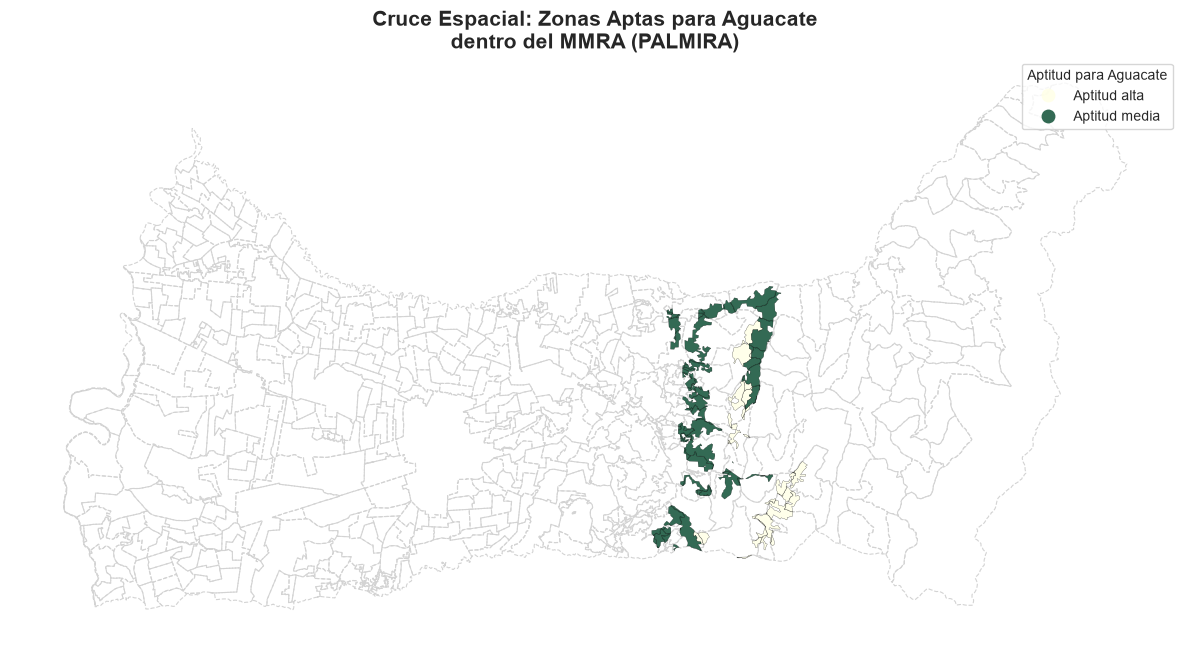


Distribución de áreas aptas para Aguacate según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,
Pastos,409.8,"1,626.9","2,036.7"
Bosque Natural,257.5,103.2,360.7
Mixto_Mixto,79.6,91.3,170.9
Mixto_2P,0.0,25.0,25.0
Cultivos Permanentes,0.0,9.6,9.6
Mixto_2C,0.0,9.2,9.2



🍍 Analizando aptitud UPRA para: Banano
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


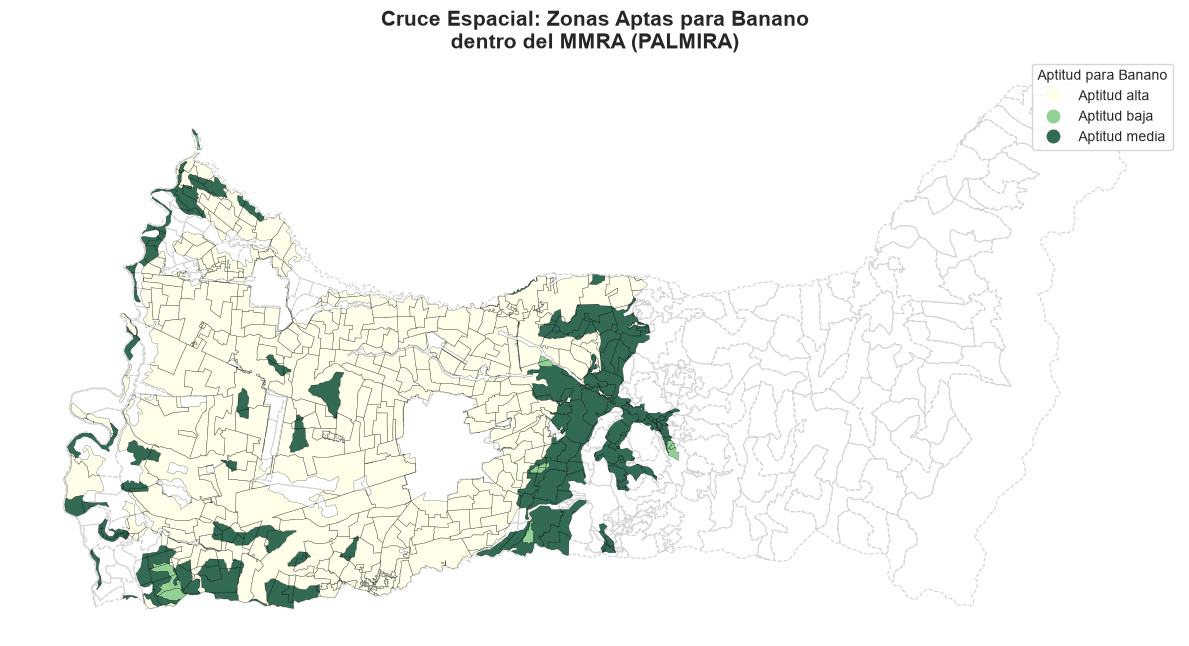


Distribución de áreas aptas para Banano según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud baja,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,,
Cultivos Permanentes,"30,638.6",329.7,"6,457.0","37,425.4"
Mixto_2C,"1,028.4",0.0,"1,109.4","2,137.8"
Pastos,122.0,27.0,"1,106.3","1,255.4"
Otros Usos y Coberturas,816.2,0.0,1.0,817.2
No Agropecuario,556.4,0.0,84.4,640.9
Mixto_1A,148.5,0.0,12.6,161.1
Mixto_4OC,22.4,0.0,0.0,22.4



🍍 Analizando aptitud UPRA para: Cacao
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


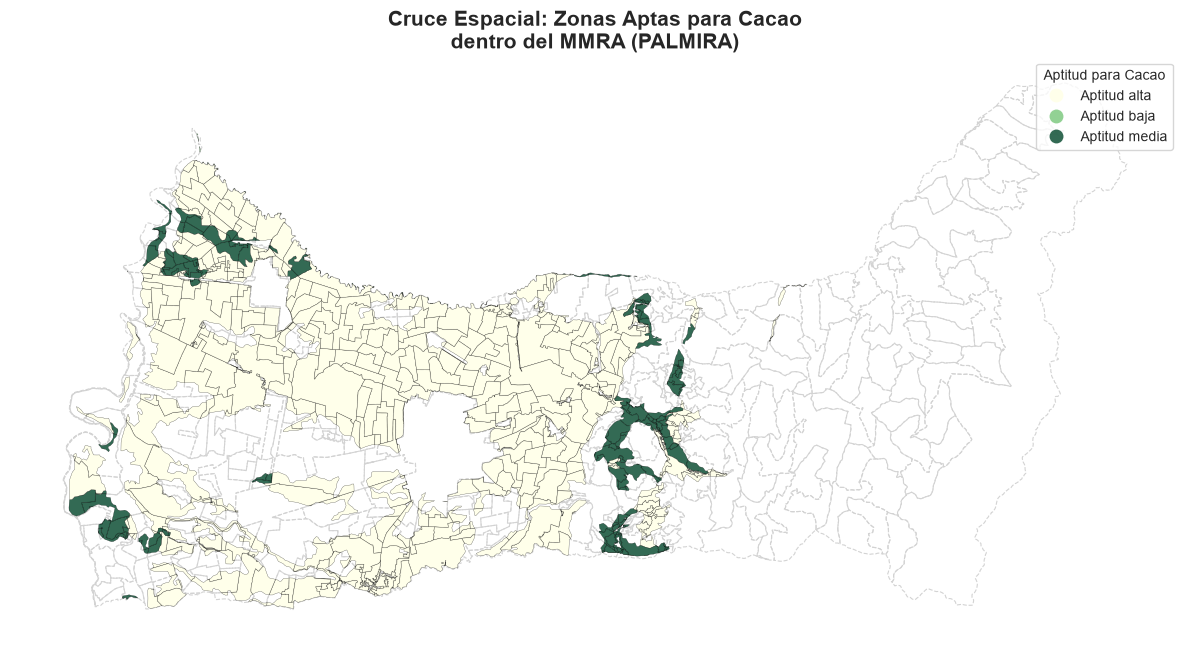


Distribución de áreas aptas para Cacao según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud baja,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,,
Cultivos Permanentes,"27,511.6",1.4,"1,508.7","29,021.7"
Pastos,"1,141.0",1.6,"1,205.9","2,348.5"
Mixto_2C,"1,898.8",0.0,334.8,"2,233.5"
No Agropecuario,472.1,0.3,122.6,595.0
Otros Usos y Coberturas,278.2,0.0,0.7,278.9
Mixto_1A,173.0,0.0,0.0,173.0
Mixto_Mixto,48.3,0.0,41.2,89.5
Mixto_4OC,22.4,0.0,0.0,22.4
Bosque Natural,21.4,0.0,0.0,21.4



🍍 Analizando aptitud UPRA para: Cafe
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


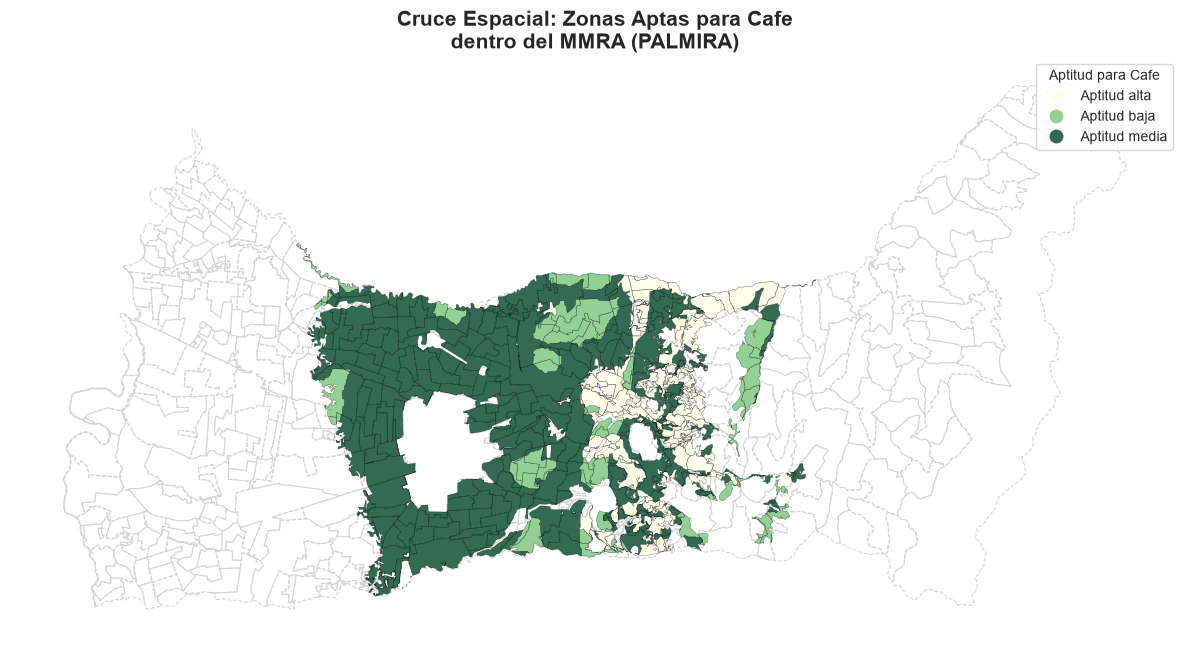


Distribución de áreas aptas para Cafe según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud baja,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,,
Cultivos Permanentes,538.3,"2,179.2","14,608.8","17,326.3"
Pastos,"2,951.0","1,066.3","2,924.0","6,941.3"
Mixto_2C,497.3,449.2,"1,004.4","1,950.9"
Otros Usos y Coberturas,0.0,0.0,337.4,337.4
Bosque Natural,52.4,150.6,101.2,304.2
Mixto_Mixto,148.2,60.2,40.8,249.1
Mixto_1A,0.0,7.5,165.5,173.0
No Agropecuario,0.1,5.6,56.8,62.5
Mixto_2P,42.9,0.0,0.7,43.5



🍍 Analizando aptitud UPRA para: Cana Panelera
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


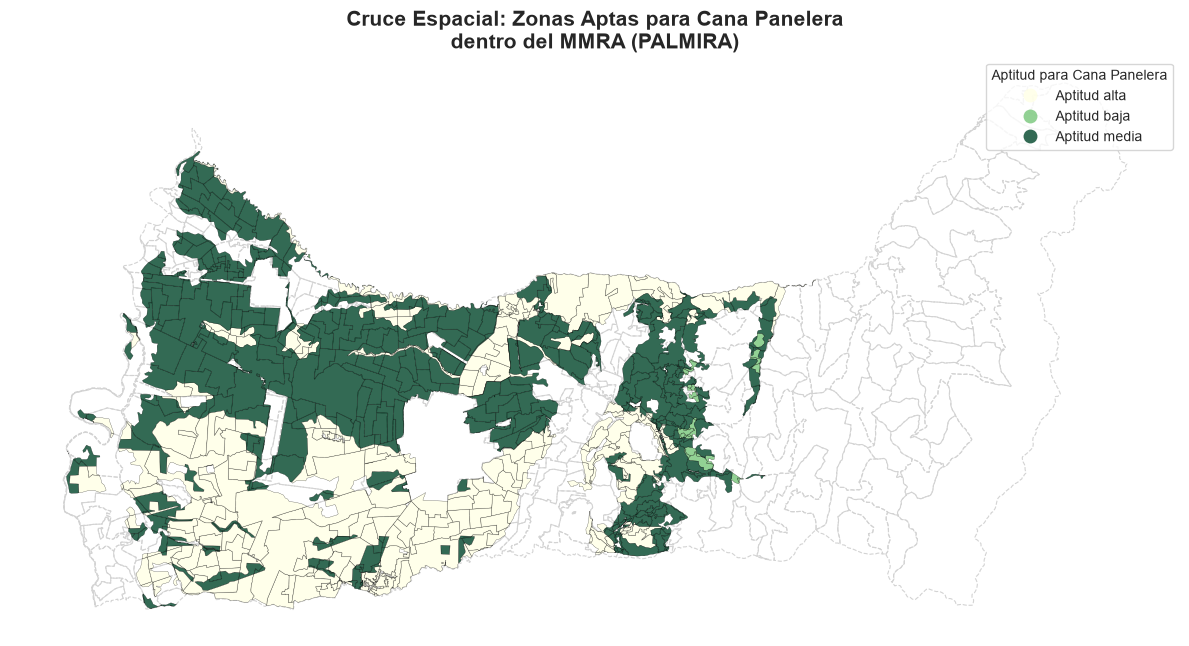


Distribución de áreas aptas para Cana Panelera según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud baja,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,,
Cultivos Permanentes,"16,417.2",8.5,"18,291.2","34,716.8"
Pastos,"1,950.6",217.1,"3,512.7","5,680.3"
Mixto_2C,589.6,4.4,"1,346.4","1,940.3"
Otros Usos y Coberturas,718.9,0.0,95.5,814.4
No Agropecuario,425.0,0.1,268.9,693.9
Mixto_Mixto,0.0,56.6,104.3,160.9
Mixto_1A,1.2,0.0,159.2,160.3
Bosque Natural,0.0,16.7,72.2,88.9
Mixto_2P,0.0,22.4,23.0,45.4



🍍 Analizando aptitud UPRA para: Fresa
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


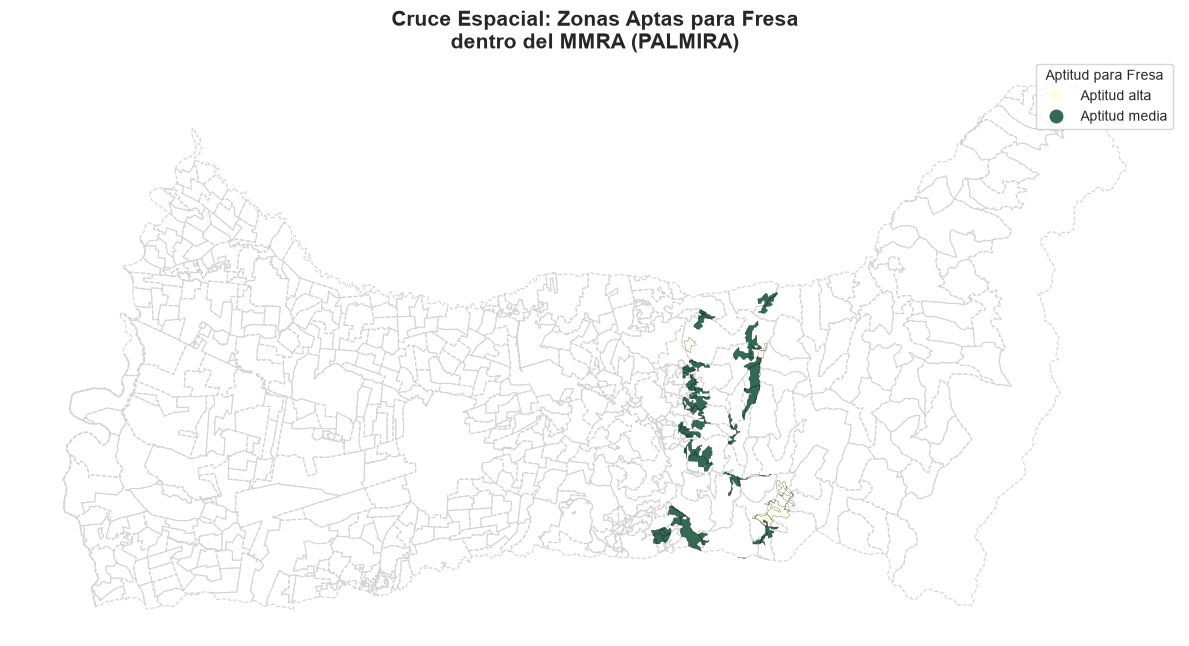


Distribución de áreas aptas para Fresa según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,
Pastos,90.1,961.2,"1,051.3"
Bosque Natural,104.2,56.7,160.9
Mixto_Mixto,35.5,87.1,122.6
Mixto_2P,0.0,18.4,18.4
Mixto_2C,0.0,8.4,8.4
Cultivos Permanentes,0.0,7.1,7.1



🍍 Analizando aptitud UPRA para: Papaya
Realizando Intersección Espacial (Spatial Join) en PALMIRA...


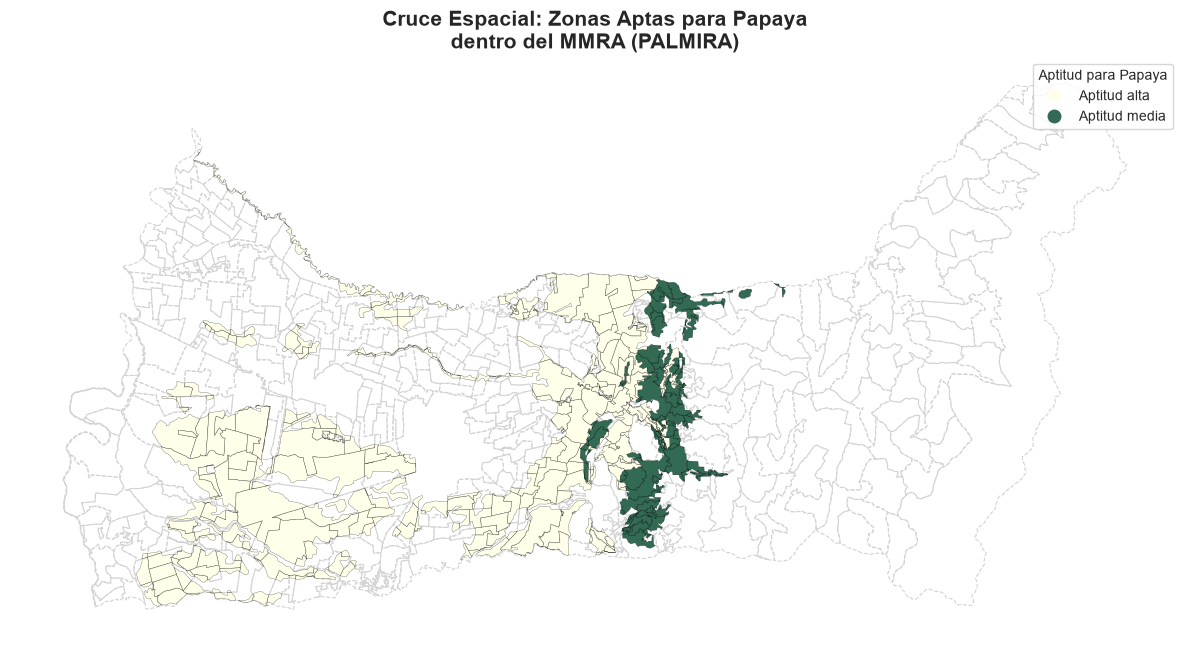


Distribución de áreas aptas para Papaya según el uso de suelo actual del MMRA (Hectáreas):



aptitud,Aptitud alta,Aptitud media,Total_Aptitud_Ha
USO_PRED_CONGL,,,
Cultivos Permanentes,"13,887.5",208.6,"14,096.1"
Pastos,"1,399.1","2,293.0","3,692.1"
Mixto_2C,"1,380.9",335.4,"1,716.3"
Otros Usos y Coberturas,534.7,0.0,534.7
No Agropecuario,257.0,12.5,269.5
Mixto_Mixto,0.0,76.7,76.7
Mixto_1A,25.1,0.0,25.1
Mixto_2P,0.0,19.1,19.1
Bosque Natural,0.0,17.5,17.5


In [9]:
if 'gdf_local' in locals() and not gdf_local.empty:
    import glob
    import geopandas as gpd
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning)
    
    # Buscar algún archivo de zonificación procesado en GeoJSON
    zonificacion_files = glob.glob(str(PROCESSED_DIR / 'zonificacion_*_valle_limpio.geojson'))
    
    if zonificacion_files:
        # Iterar sobre todos los cultivos disponibles (mostramos el análisis para cada uno o el primero)
        for z_file in zonificacion_files:
            cultivo_nombre = Path(z_file).name.split('zonificacion_')[-1].split('_valle')[0].replace('_', ' ').title()
            print(f"\n{'='*60}\n🍍 Analizando aptitud UPRA para: {cultivo_nombre}\n{'='*60}")
            
            try:
                gdf_crop = gpd.read_file(z_file)
                
                # Filtrar municipio para agilizar el proceso espacial
                if 'municipio' in gdf_crop.columns:
                    gdf_crop_local = gdf_crop[gdf_crop['municipio'].str.upper().str.strip() == municipio_objetivo]
                else:
                    gdf_crop_local = gdf_crop
                    
                if not gdf_crop_local.empty:
                    # Unificar Sistema de Coordenadas (CRS)
                    if gdf_crop_local.crs != gdf_local.crs:
                        gdf_crop_local = gdf_crop_local.to_crs(gdf_local.crs)
                    
                    # Solo nos interesan las aptitudes Alta y Media para viabilidad
                    aptitudes_utiles = ['Aptitud alta', 'Aptitud media', 'Aptitud baja']
                    gdf_crop_apt = gdf_crop_local[gdf_crop_local['aptitud'].isin(aptitudes_utiles)]
                    
                    if gdf_crop_apt.empty:
                        print(f"No hay áreas aptas para {cultivo_nombre} en {municipio_objetivo}.")
                        continue
                        
                    print(f"Realizando Intersección Espacial (Spatial Join) en {municipio_objetivo}...")
                    # Overlay cruza físicamente los polígonos
                    interseccion = gpd.overlay(gdf_local, gdf_crop_apt, how='intersection')
                    
                    if not interseccion.empty:
                        # Visualización
                        fig, ax = plt.subplots(figsize=(12, 10))
                        
                        # Fondo: Conglomerados MMRA
                        gdf_local.plot(ax=ax, facecolor='none', edgecolor='lightgray', linewidth=0.8, linestyle='--')
                        
                        # Frente: Polígonos de aptitud recortados por el MMRA
                        interseccion.plot(column='aptitud', 
                                          ax=ax, 
                                          legend=True, 
                                          cmap='YlGn', 
                                          alpha=0.8,
                                          edgecolor='black', 
                                          linewidth=0.2,
                                          legend_kwds={'title': f'Aptitud para {cultivo_nombre}'})
                        
                        ax.set_title(f'Cruce Espacial: Zonas Aptas para {cultivo_nombre}\ndentro del MMRA ({municipio_objetivo})', fontsize=15, fontweight='bold')
                        ax.axis('off')
                        plt.tight_layout()
                        plt.show()
                        
                        # Resumen estadístico (Cálculo de Área Geoespacial Real)
                        # Proyectamos a Magna Sirgas EPSG:3116 para medir área en metros cuadrados, luego / 10000 para Hectáreas
                        interseccion['area_cruce_ha'] = interseccion.to_crs("EPSG:3116").geometry.area / 10000
                        
                        print(f"\nDistribución de áreas aptas para {cultivo_nombre} según el uso de suelo actual del MMRA (Hectáreas):\n")
                        resumen_cruce = interseccion.groupby(['USO_PRED_CONGL', 'aptitud'])['area_cruce_ha'].sum().unstack().fillna(0)
                        if not resumen_cruce.empty:
                            resumen_cruce['Total_Aptitud_Ha'] = resumen_cruce.sum(axis=1)
                            display(resumen_cruce.sort_values(by='Total_Aptitud_Ha', ascending=False).style.format('{:,.1f}'))
                    else:
                        print(f"La intersección resultó vacía para {cultivo_nombre} y los polígonos del MMRA.")
                        
                else:
                    print(f"No hay polígonos base de {cultivo_nombre} en {municipio_objetivo}.")
            except Exception as e:
                print(f"Error procesando capa espacial de {cultivo_nombre}: {e}")
    else:
        print("No se encontraron archivos GeoJSON de zonificación en data/processed/.")
        print("Asegúrate de haber ejecutado los scripts de zonificación (ej. python scripts/run_all_zonificaciones.py)")